In [164]:
import numpy as np
import random

# Define fitness function f(X)
def eta(x, theta):
    return theta[2] * (np.exp(-theta[1] * x) - np.exp(-theta[0] * x))

# Define the gradient of f(X) with respect to theta
def gradient_eta(x, theta):
    gradient = np.zeros(3)
    gradient[0] = x * theta[2] * np.exp(-theta[0] * x)
    gradient[1] = -x * theta[2] * np.exp(-theta[1] * x)
    gradient[2] = np.exp(-theta[1] * x) - np.exp(-theta[0] * x)
    return gradient

# Calculate the information matrix for a given set of X values, weights, and theta values
def information_matrix(X, weights, theta):
    num_parameters = len(theta)
    M = np.zeros((num_parameters, num_parameters))
    for i, x in enumerate(X):
        grad = gradient_eta(x, theta)
        M += weights[i] * np.outer(grad, grad)
    return M

# Define objective function 
def fitness_function(X, weights, theta):
    num_points = 3  # Number of x points
    X_points = X[:num_points]
    M = information_matrix(X_points, weights, theta)
    try:
        return -np.log(np.linalg.det(M))
    except ValueError:
        return np.inf  # If the matrix is not positive definite, return a large value

# Particle Swarm Optimization function
def pso(num_particles, num_dimensions, max_iter, theta):
    num_points = 3
    # Initialize particles
    positions = np.random.uniform(0.1, 30, size=(num_particles, num_dimensions))
    velocities = np.zeros((num_particles, num_dimensions))
    weights = positions[:, -num_points:]  # Extract weights from positions
    weights /= weights.sum(axis=1, keepdims=True)  # Normalize weights
    personal_best_positions = np.copy(positions)
    personal_best_values = [fitness_function(position[:num_points], position[-num_points:], theta) for position in positions]
    global_best_index = np.argmin(personal_best_values)
    global_best_position = personal_best_positions[global_best_index]
    global_best_value = personal_best_values[global_best_index]

    # Define the search space limits
    lower_bound = np.full(num_dimensions, 0.1)
    upper_bound = np.full(num_dimensions, 30)

    # PSO iterations
    for _ in range(max_iter):
        for i in range(num_particles):
            inertia_weight = random.uniform(0.4, 0.9)
            cognitive_factor = 2
            social_factor = 2
            beta1 = np.random.rand(num_dimensions)
            beta2 = np.random.rand(num_dimensions)
            velocity_update = (inertia_weight * velocities[i] +
                               cognitive_factor * beta1 * (personal_best_positions[i] - positions[i]) +
                               social_factor * beta2 * (global_best_position - positions[i]))
            positions[i] += velocity_update
            velocities[i] = velocity_update

            # Enforce position limits
            positions[i] = np.maximum(np.minimum(positions[i], upper_bound), lower_bound)
            weights[i] = positions[i, -num_points:]
            weights[i] /= weights[i].sum()  # Normalize weights

            # Update personal best positions and values
            current_value = fitness_function(positions[i, :num_points], weights[i], theta)
            if current_value < personal_best_values[i]:
                personal_best_positions[i] = positions[i]
                personal_best_values[i] = current_value

        # Update global best position and value
        new_global_best_index = np.argmin(personal_best_values)
        new_global_best_value = personal_best_values[new_global_best_index]
        if new_global_best_value < global_best_value:
            global_best_index = new_global_best_index
            global_best_position = personal_best_positions[global_best_index]
            global_best_value = new_global_best_value

    return global_best_position, global_best_value
# Example usage
num_particles = 100
num_dimensions = 6  # Three x values and three weights
max_iterations = 100
theta = [0.05884, 4.298, 21.8]  # Example theta values

best_position, best_value = pso(num_particles, num_dimensions, max_iterations, theta)
print("Global best position (x1, x2, x3, w1, w2):", best_position[:5])  # Only print the first five elements
print("Global best value:", best_value)

C:\Users\user\AppData\Local\Temp\ipykernel_31600\1780350886.py:31: RuntimeWarning: invalid value encountered in log
  return -np.log(np.linalg.det(M))


Global best position (x1, x2, x3, w1, w2): [18.41600449  1.38848233  0.22876143  0.33334237  0.33335216]
Global best value: -7.388692367718574


In [1]:
import numpy as np
import random

# Define fitness function f(X)
def fitness_function(X, theta):
    x = X[0]
    return theta[2] * (np.exp(-theta[1]*x) - np.exp(-theta[0]*x))

# Define objective function h() for the PSO algorithm
def objective_function(X, W, theta):
    x1, x2, x3 = X
    w1, w2, w3= W
    term1 = np.array([                                # Define the first term of the objective function
        x1 * theta[2] * np.exp(-theta[0]*x1),
        -x1 * theta[2] * np.exp(-theta[1]*x1),
        np.exp(-theta[1]*x1) - np.exp(-theta[0]*x1)
    ])
    term2 = np.array([                                # Define the second term of the objective function
        x2 * theta[2] * np.exp(-theta[0]*x2),
        -x2 * theta[2] * np.exp(-theta[1]*x2),
        np.exp(-theta[1]*x2) - np.exp(-theta[0]*x2)
    ])
    term3 = np.array([                                 # Define the third term of the objective function
        x3 * theta[2] * np.exp(-theta[0]*x3),
        -x3 * theta[2] * np.exp(-theta[1]*x3),
        np.exp(-theta[1]*x3) - np.exp(-theta[0]*x3)
    ])    
    matrix_sum = w1*np.outer(term1, term1) + w2*np.outer(term2, term2) + w3*np.outer(term3, term3)    # compute information matrix
    return -np.log(np.linalg.det(matrix_sum))   

def pso(num_particles, num_dimensions, max_iter, theta):
    # Initialize particles
    positions = np.random.uniform(0, 1, size=(num_particles, num_dimensions))
    velocities = np.zeros((num_particles, num_dimensions))
    personal_best_positions = np.copy(positions)
    personal_best_values = [objective_function(positions[i, :3], positions[i, 3:], theta) for i in range(num_particles)]
    global_best_index = np.argmin(personal_best_values)
    global_best_position = personal_best_positions[global_best_index]
    global_best_value = personal_best_values[global_best_index]

    # Define the search space limits
    lower_bound = np.full(num_dimensions, 0)
    upper_bound = np.full(num_dimensions, 30)

    # PSO iterations
    for _ in range(max_iter):
        for i in range(num_particles):
            inertia_weight = random.uniform(0.4, 0.9)
            cognitive_factor = 2
            social_factor = 2
            beta1 = np.random.rand(num_dimensions)
            beta2 = np.random.rand(num_dimensions)
            velocity_update = (inertia_weight * velocities[i] +
                               cognitive_factor * beta1 * (personal_best_positions[i] - positions[i]) +
                               social_factor * beta2 * (global_best_position - positions[i]))
            positions[i] += velocity_update
            velocities[i] = velocity_update

            # Enforce position limits 
            positions[i] = np.maximum(np.minimum(positions[i], upper_bound), lower_bound)
            w = positions[i, 3:]            
            w = np.maximum(np.minimum(w, 1), 0)
            w = w / w.sum() # Normalize weights
            positions[i, 3:] = w
            # Extract x and w values
            x = positions[i, :3]


            # Ensure w1 and w2 are within [0, 1] and the sum of w1, w2, and w3 is 1

            # Update personal best positions and values
            current_value = objective_function(x, w, theta)
            if current_value < personal_best_values[i]:
                personal_best_positions[i] = positions[i]
                personal_best_values[i] = current_value

        # Update global best position and value
        new_global_best_index = np.argmin(personal_best_values)
        new_global_best_value = personal_best_values[new_global_best_index]
        if new_global_best_value < global_best_value:
            global_best_index = new_global_best_index
            global_best_position = personal_best_positions[global_best_index]
            global_best_value = new_global_best_value
        
    return global_best_position, global_best_value


# Example usage
num_particles = 100
num_dimensions = 6  # Three x values and two weights
max_iterations = 100
theta = [0.05884, 4.298, 21.8]  # Example theta values

best_position, best_value = pso(num_particles, num_dimensions, max_iterations, theta)
print("Global best position (x1, x2, x3, w1, w2):", best_position[:5])
print("Global best value:", best_value)


C:\Users\user\AppData\Local\Temp\ipykernel_43692\2691301288.py:29: RuntimeWarning: invalid value encountered in log
  return -np.log(np.linalg.det(matrix_sum))
C:\Users\user\AppData\Local\Temp\ipykernel_43692\2691301288.py:29: RuntimeWarning: divide by zero encountered in log
  return -np.log(np.linalg.det(matrix_sum))


Global best position (x1, x2, x3, w1, w2): [18.41759478  1.38860255  0.22876607  0.33331784  0.33333188]
Global best value: -7.388692375956017


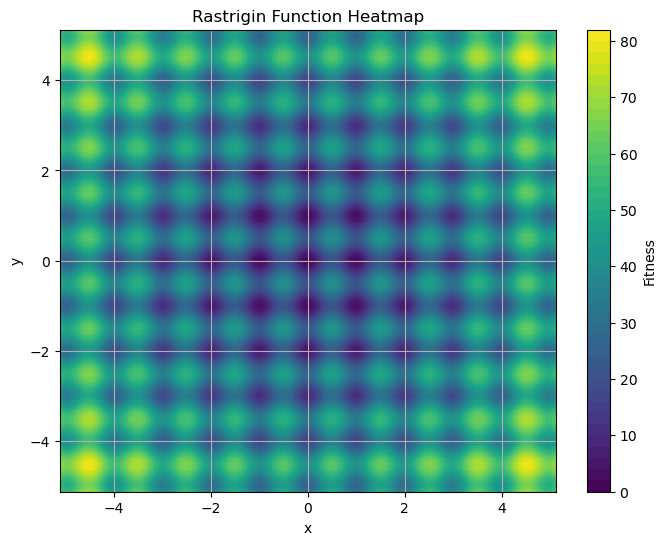

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Define the Rastrigin function
def rastrigin(x, y):
    A = 10
    return A * 2 + x**2 - A * np.cos(2 * np.pi * x) + y**2 - A * np.cos(2 * np.pi * y)

# Generate grid points for plotting
x_values = np.linspace(-5.12, 5.12, 100)
y_values = np.linspace(-5.12, 5.12, 100)
X, Y = np.meshgrid(x_values, y_values)
Z = rastrigin(X, Y)

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(label='Fitness')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Rastrigin Function Heatmap')
plt.grid(True)
plt.show()


Global best value: 24.077694256954885


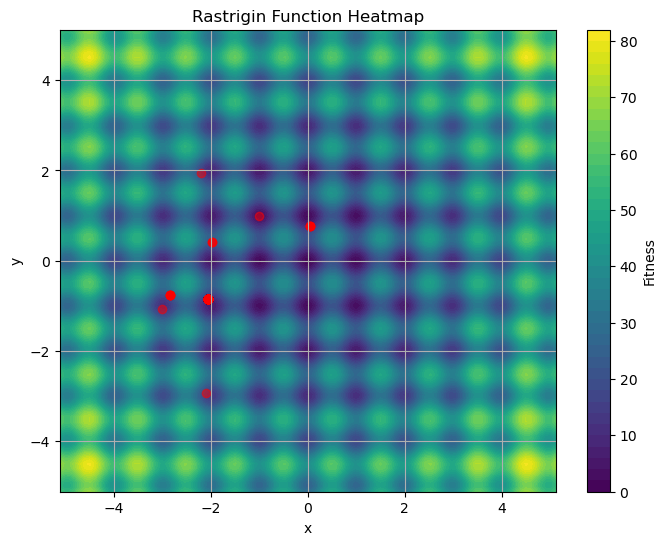

In [26]:
import numpy as np
import random
import matplotlib.pyplot as plt

def fitness_function(X):
    A = 10
    n = X.shape[0]  # Assuming X is a 2D array
    sum_part = np.sum(np.square(X) - A * np.cos(2 * np.pi * X), axis=0)
    result = A * n + sum_part
    return result

def pso(num_particles, num_dimensions, max_iter):
    # Initialize particles within the search domain
    positions = np.random.uniform(-5.12, 5.12, size=(num_particles, num_dimensions))
    velocities = np.zeros((num_particles, num_dimensions))
    personal_best_positions = np.copy(positions)
    personal_best_values = [fitness_function(position) for position in positions]
    global_best_index = np.argmin(personal_best_values)
    global_best_position = personal_best_positions[global_best_index]
    global_best_value = personal_best_values[global_best_index]

    # Track global best position at each iteration
    global_best_positions = [global_best_position]

    # PSO iterations
    for _ in range(max_iter):
        # Update velocities and positions
        for i in range(num_particles):
            inertia_weight = random.uniform(0.4, 0.9)
            cognitive_factor = 2
            social_factor = 2
            beta1 = np.random.rand(num_dimensions)
            beta2 = np.random.rand(num_dimensions)
            velocity_update = (inertia_weight * velocities[i] +
                               cognitive_factor * beta1 * (personal_best_positions[i] - positions[i]) +
                               social_factor * beta2 * (global_best_position - positions[i]))
            positions[i] += velocity_update
            velocities[i] = velocity_update

            # Ensure particles stay within the search domain
            positions[i] = np.maximum(np.minimum(positions[i], 5.12), -5.12)

            # Update personal best positions and values
            current_value = fitness_function(positions[i])
            if current_value < personal_best_values[i]:
                personal_best_positions[i] = positions[i]
                personal_best_values[i] = current_value

        # Update global best position and value
        new_global_best_index = np.argmin(personal_best_values)
        new_global_best_value = personal_best_values[new_global_best_index]
        if new_global_best_value < global_best_value:
            global_best_index = new_global_best_index
            global_best_position = personal_best_positions[global_best_index]
            global_best_value = new_global_best_value

        # Record global best position at this iteration
        global_best_positions.append(global_best_position)

    return global_best_positions, global_best_value

# Example usage
num_particles = 50
num_dimensions = 10  # Number of dimensions (variables)
max_iterations = 100

# Run PSO algorithm
global_best_positions, best_value = pso(num_particles, num_dimensions, max_iterations)
print("Global best value:", best_value)

# Generate grid points for plotting Rastrigin function
x = np.linspace(-5.12, 5.12, 100)
y = np.linspace(-5.12, 5.12, 100)
X, Y = np.meshgrid(x, y)
Z = fitness_function(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

# Plot Rastrigin function heatmap
plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(label='Fitness')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Rastrigin Function Heatmap')

# Plot global best positions
for position in global_best_positions:
    plt.scatter(position[0], position[1], color='red', alpha=0.5)

plt.grid(True)
plt.show()
